In [ ]:
#!/usr/bin/python .venv

# Laboratorio #6 - Análisis de tráfico de red


## Análisis estadístico


### Cargar el archvio


In [1]:
from scapy.all import rdpcap

# Asignar el archivo .pcap a una variable
pcap_file = "analisis_paquetes.pcap"
packets = rdpcap(pcap_file)

# Verifica el tipo y cantidad de paquetes
print(type(packets))
print(len(packets))
print(packets.summary())

<class 'scapy.plist.PacketList'>
62
Ether / IP / UDP / DNS Qry b'google.com.' / Raw
Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807::200e
Ether / IP / UDP / DNS Qry b'google.com.' / Raw
Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807::200e
Ether / IP / UDP / DNS Qry b'google.com.' / Raw
Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807::200e
Ether / IP / UDP / DNS Qry b'google.com.' / Raw
Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807::200e
Ether / IP / UDP / DNS Qry b'google.com.' / Raw
Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807::200e
Ether / IP / UDP / DNS Qry b'google.com.' / Raw
Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807::200e
Ether / IP / UDP / DNS Qry b'google.com.' / Raw
Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807::200e
Ether / IP / UDP / DNS Qry b'google.com.' / Raw
Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807::200e
Ether / IP / UDP / DNS Qry b'google.com.' / Raw
Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807::200e
Ether / IP / UDP / DNS Qry b'google.com.' / Raw
Ether / IP / UDP

### Convertirlo a un Dataframe


In [3]:
import pandas as pd

# Lista para almacenar la info de cada paquete
packet_data = []

for pkt in packets:
    if pkt.haslayer("IP"):  # Solo si tiene capa IP
        src = pkt["IP"].src
        dst = pkt["IP"].dst
        sport = pkt.sport if hasattr(pkt, "sport") else None
        dport = pkt.dport if hasattr(pkt, "dport") else None
        payload_len = len(pkt.payload)

        packet_data.append(
            {
                "src": src,
                "dst": dst,
                "sport": sport,
                "dport": dport,
                "payload_len": payload_len,
                "time": pkt.time,
            }
        )

# Convertir a DataFrame
df = pd.DataFrame(packet_data)

# Mostrar las primeras filas
df.head(5)

,src,dst,sport,dport,payload_len,time
0,10.1.10.53,84.54.22.33,53,53,961,1532199330.917674
1,84.54.22.33,10.1.10.53,53,53,84,1532199330.950107
2,10.1.10.53,84.54.22.33,53,53,975,1532199331.937777
3,84.54.22.33,10.1.10.53,53,53,84,1532199331.956635
4,10.1.10.53,84.54.22.33,53,53,1012,1532199332.960504


### Estadísticas

#### Mostrar todas las IP origen única

In [4]:
ip_origenes = df["src"].unique()
print("IPs origen únicas:")
print(ip_origenes)

IPs origen únicas:
['10.1.10.53' '84.54.22.33' '75.75.75.75']


In [5]:
# Contar ocurrencias de cada IP origen
conteo_ip_origen = df["src"].value_counts()
print("Conteo de IPs origen:")
print(conteo_ip_origen)

Conteo de IPs origen:
src
10.1.10.53     31
84.54.22.33    29
75.75.75.75     2
Name: count, dtype: int64


#### Mostrar todas las IP destino

In [6]:
# Mostrar todas las IP destino únicas
ip_destinos = df["dst"].unique()
print("IPs destino únicas:")
print(ip_destinos)

IPs destino únicas:
['84.54.22.33' '10.1.10.53' '75.75.75.75']


In [7]:
# Contar ocurrencias de cada IP destino
conteo_ip_destino = df["dst"].value_counts()
print("Conteo de IPs destino:")
print(conteo_ip_destino)

Conteo de IPs destino:
dst
10.1.10.53     31
84.54.22.33    29
75.75.75.75     2
Name: count, dtype: int64


#### ¿Cuál es la IP de origen más frecuente?

IP origen `10.1.10.53`

##### ¿A qué IP destino se comunica con más frecuencia?

In [8]:
# Filtrar solo paquetes donde la IP origen es 10.1.10.53
df_origen_10 = df[df["src"] == "10.1.10.53"]

# Contar las IP destino a las que se comunica esa IP origen
destinos_mas_frecuentes = df_origen_10["dst"].value_counts()

print("Destinos más frecuentes para 10.1.10.53:")
print(destinos_mas_frecuentes)

Destinos más frecuentes para 10.1.10.53:
dst
84.54.22.33    29
75.75.75.75     2
Name: count, dtype: int64


IP de destino más frecuente `84.54.22.33`

##### ¿A que puerto destino se comunica? ¿Cuál es el propósito de este puerto?

In [9]:
# Contar los puertos destino a los que se comunica 10.1.10.53
puertos_destino_frecuentes = df_origen_10["dport"].value_counts()

print("Puertos destino más frecuentes para 10.1.10.53:")
print(puertos_destino_frecuentes)

Puertos destino más frecuentes para 10.1.10.53:
dport
53    31
Name: count, dtype: int64


* **Puerto de destino**: `53` (DNS)
* **Propostio**: DNS (Domain Name System) es un sistema que traduce nombres de dominio legibles por humanos (como www.ejemplo.com) en direcciones IP numéricas (como 192.168.1.1), que son necesarias para localizar y acceder a dispositivos en la red de Internet.

Referencia: https://books.spartan-cybersec.com/cppj/networking-for-juniors/puertos-y-servicios/puerto-53-dns

##### ¿Desde que puertos origen se comunica?

In [10]:
# Contar los puertos origen desde los que se comunica 10.1.10.53
puertos_origen_frecuentes = df_origen_10["sport"].value_counts()

print("Puertos origen más frecuentes para 10.1.10.53:")
print(puertos_origen_frecuentes)

Puertos origen más frecuentes para 10.1.10.53:
sport
53       29
15812     1
23903     1
Name: count, dtype: int64


* **Puertos de origen**:
    * 53
    * 15812
    * 23903

### Gráficas

#### a. Genere una gráfica de barras 2D horizontales, en el eje Y las IPs origen, y en el eje X lasuma de los payloads (bytes) enviados desde dichas direcciones.

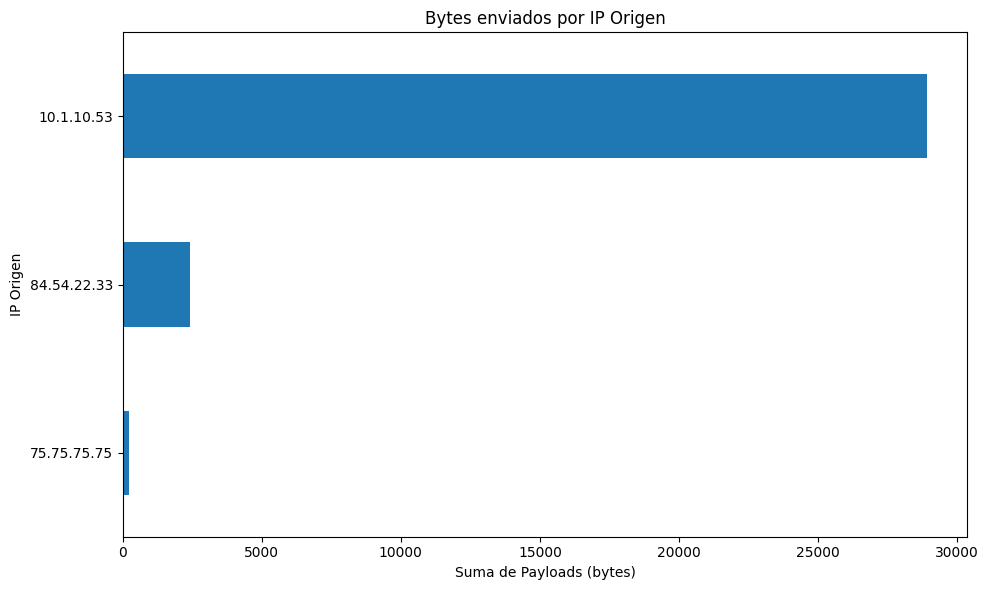

In [11]:
import matplotlib.pyplot as plt

# Agrupar por IP origen y sumar los payloads
payloads_por_ip_origen = df.groupby("src")["payload_len"].sum().sort_values(ascending=True)

# Crear la gráfica
plt.figure(figsize=(10, 6))
payloads_por_ip_origen.plot(kind="barh")
plt.xlabel("Suma de Payloads (bytes)")
plt.ylabel("IP Origen")
plt.title("Bytes enviados por IP Origen")
plt.tight_layout()
plt.show()

#### b. Genere una gráfica de barras 2D horizontales, en el eje Y las IP destino, y en el eje X la suma de los payloads (bytes) recibidos en dichas direcciones.

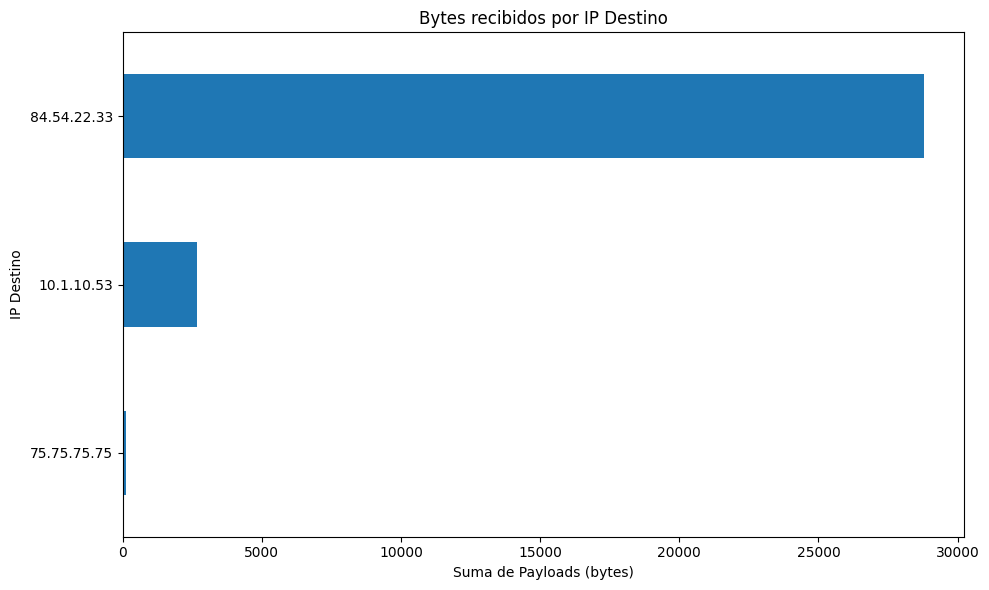

In [12]:
# Agrupar por IP destino y sumar los payloads recibidos
payloads_por_ip_destino = df.groupby("dst")["payload_len"].sum().sort_values(ascending=True)

# Crear la gráfica
plt.figure(figsize=(10, 6))
payloads_por_ip_destino.plot(kind="barh")
plt.xlabel("Suma de Payloads (bytes)")
plt.ylabel("IP Destino")
plt.title("Bytes recibidos por IP Destino")
plt.tight_layout()
plt.show()

#### c. Genere una gráfica de barras 2D horizontales, en el eje Y los puertos origen, y en el eje X la suma de los payloads (bytes) enviados de dichos puertos.

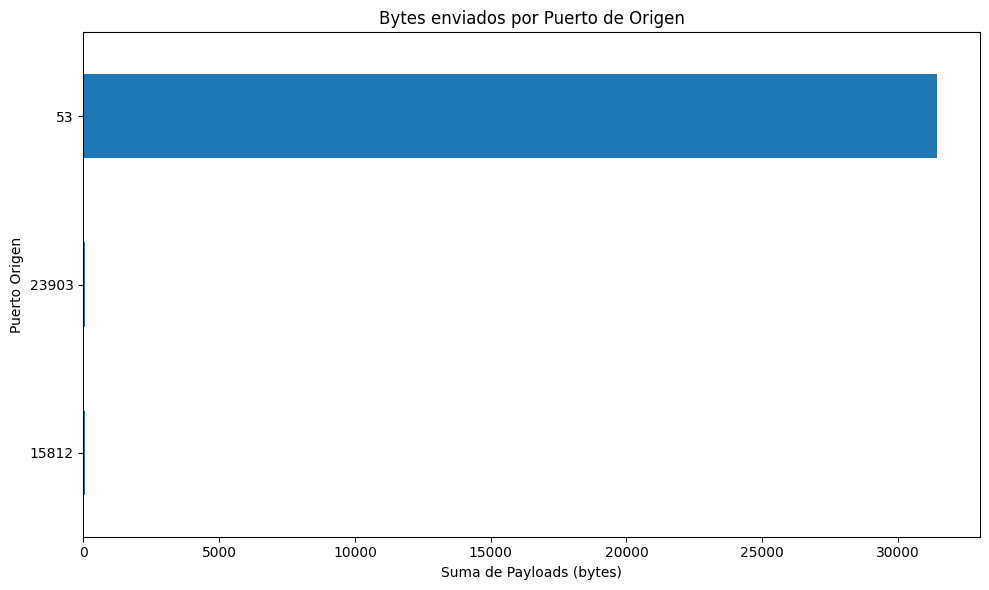

In [13]:
# Agrupar por puerto de origen y sumar los payloads enviados
payloads_por_puerto_origen = df.groupby("sport")["payload_len"].sum().sort_values(ascending=True)

# Crear la gráfica
plt.figure(figsize=(10, 6))
payloads_por_puerto_origen.plot(kind="barh")
plt.xlabel("Suma de Payloads (bytes)")
plt.ylabel("Puerto Origen")
plt.title("Bytes enviados por Puerto de Origen")
plt.tight_layout()
plt.show()

#### d. Genere una gráfica 2D de barras horizontales, en el eje Y los puertos destino, y en el eje X la suma de los payloads (bytes) recibidos en dichos puertos.

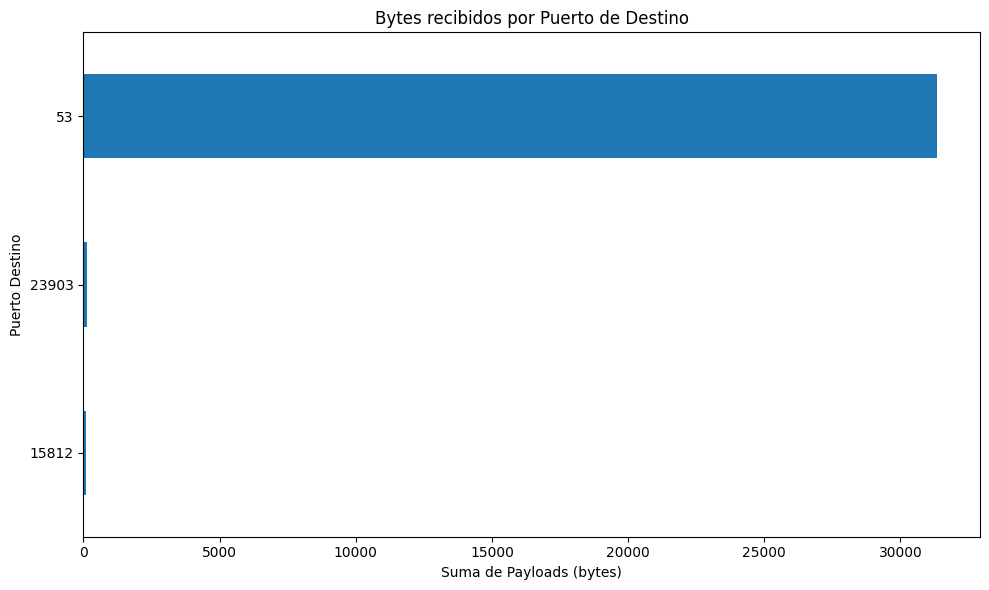

In [14]:
# Agrupar por puerto de destino y sumar los payloads recibidos
payloads_por_puerto_destino = df.groupby("dport")["payload_len"].sum().sort_values(ascending=True)

# Crear la gráfica
plt.figure(figsize=(10, 6))
payloads_por_puerto_destino.plot(kind="barh")
plt.xlabel("Suma de Payloads (bytes)")
plt.ylabel("Puerto Destino")
plt.title("Bytes recibidos por Puerto de Destino")
plt.tight_layout()
plt.show()

#### e. Genere una gráfica de barras 2D verticales, en el eje Y la suma de los payload, en el eje X el tiempo, para la IP origen más frecuente.

/var/folders/h8/k3gpg6h97wv_mzlyws73msh80000gn/T/ipykernel_58970/16273591.py:5: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_10["time_rounded"] = pd.to_datetime(df_10["time"].astype(float), unit='s').dt.floor("S")


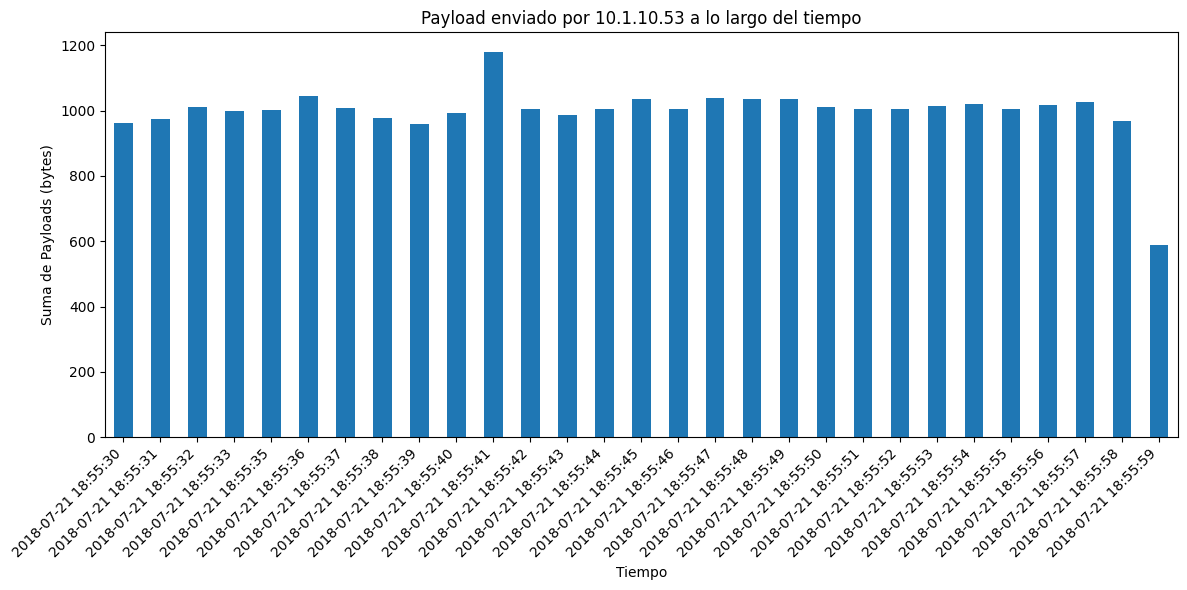

In [16]:
# Filtrar solo paquetes de la IP origen más frecuente
df_10 = df[df["src"] == "10.1.10.53"].copy()

# Redondear el tiempo a segundos (opcional: puedes agrupar por segundos o minutos según convenga)
df_10["time_rounded"] = pd.to_datetime(df_10["time"].astype(float), unit='s').dt.floor("S")

# Agrupar por tiempo y sumar payloads
payloads_por_tiempo = df_10.groupby("time_rounded")["payload_len"].sum()

# Crear la gráfica
plt.figure(figsize=(12, 6))
payloads_por_tiempo.plot(kind="bar")
plt.ylabel("Suma de Payloads (bytes)")
plt.xlabel("Tiempo")
plt.title("Payload enviado por 10.1.10.53 a lo largo del tiempo")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### f. Utilizando la información de las estadísticas y la información del comportamiento del tráfico que las gráficas muestran, describa que es lo que está sucediendo. ¿Es común el comportamiento?

1. IP origen más activa: 10.1.10.53
	* Es la IP que más paquetes ha enviado.
	* Se comunica principalmente con la IP 84.54.22.33.

2. IP destino más frecuente: 84.54.22.33
	* Recibe la mayor cantidad de datos desde 10.1.10.53.

3. Puerto destino más común: 53
	* Este puerto está asociado al servicio DNS (Domain Name System).
	* Indica que el tráfico está relacionado con consultas de resolución de nombres.

4. Puertos origen:
	* Se observan puertos efímeros (por ejemplo, 23903, 15812), lo cual es típico del cliente al iniciar conexiones.
	* También hay tráfico desde el puerto 53, lo que podría indicar que 10.1.10.53 también está actuando como servidor DNS, lo cual no es común si esta IP pertenece a un cliente típico.

5. Payloads a lo largo del tiempo
	* El volumen de datos enviados por segundo se mantiene relativamente constante, con ligeras variaciones.
	* No hay picos bruscos, lo que sugiere un comportamiento automatizado o regular.

Es normal sí, si:
* 10.1.10.53 es un servidor DNS interno dentro de una red corporativa o universitaria.
* En ese caso, es normal que se comunique constantemente con clientes o servidores externos para resolver nombres de dominio.

No, si: 
* No es típico que un cliente se comunique tanto con el puerto 53 de forma tan constante.
* Tampoco es común que un cliente use el puerto 53 como origen, lo que sugiere que puede estar respondiendo consultas → esto implicaría un comportamiento sospechoso como:
* Actuar como DNS sin autorización.
* Ser parte de una botnet o malware que utiliza DNS para comunicación encubierta.

pero una ip 10.1... comunmente se usa como una ip privada (interna)

1. Servidor DNS interno legítimo → tráfico normal.
2. Cliente que actúa como servidor DNS (intencional o no) → comportamiento sospechoso o malicioso.
3. DNS tunneling: técnica usada por malware para evadir firewalls y extraer datos a través de tráfico DNS.


### Investigación del payload

#### a. Cree un nuevo DF que incluya únicamente las conexiones con la dirección IP origen más frecuente.

In [17]:
# Crear un nuevo DataFrame con conexiones desde la IP origen más frecuente
ip_mas_frecuente = df["src"].value_counts().idxmax()  # Esto obtiene automáticamente la IP más frecuente
df_ip_frecuente = df[df["src"] == ip_mas_frecuente].copy()

# Ver las primeras filas para verificar
df_ip_frecuente.head()

,src,dst,sport,dport,payload_len,time
0,10.1.10.53,84.54.22.33,53,53,961,1532199330.917674
2,10.1.10.53,84.54.22.33,53,53,975,1532199331.937777
4,10.1.10.53,84.54.22.33,53,53,1012,1532199332.960504
6,10.1.10.53,84.54.22.33,53,53,998,1532199333.982248
8,10.1.10.53,84.54.22.33,53,53,1003,1532199335.003376


#### b. Cree un nuevo DF que utilice el DF anterior con las columnas src, dst y payload y agrúpelas por dst y la suma del payload

In [18]:
# Seleccionar columnas necesarias
df_dst_payload = df_ip_frecuente[["src", "dst", "payload_len"]]

# Agrupar por destino y sumar los payloads
df_payload_por_destino = df_dst_payload.groupby("dst")["payload_len"].sum().reset_index()

# Mostrar el resultado
df_payload_por_destino

,dst,payload_len
0,75.75.75.75,130
1,84.54.22.33,28791


#### c. Obtenga la IP destino que más ha intercambiado bytes con la IP más frecuente. Esta IP es sospechosa por la cantidad de bytes intercambiados, entre todas las direcciones.

In [19]:
# Obtener la IP destino con mayor cantidad de bytes intercambiados
ip_destino_top = df_payload_por_destino.loc[df_payload_por_destino["payload_len"].idxmax()]

print("La IP destino que más ha intercambiado bytes con la IP origen más frecuente es:")
print(ip_destino_top)

La IP destino que más ha intercambiado bytes con la IP origen más frecuente es:
dst            84.54.22.33
payload_len          28791
Name: 1, dtype: object


#### d. Cree un nuevo DF con la conversación entre la IP más frecuente y la IP sospechosa.

In [20]:
# Extraer IPs de interés
ip_origen_frecuente = ip_mas_frecuente
ip_destino_sospechosa = ip_destino_top["dst"]

# Filtrar todas las filas donde haya comunicación entre estas dos IPs (en cualquier dirección)
df_conversacion = df[
    ((df["src"] == ip_origen_frecuente) & (df["dst"] == ip_destino_sospechosa)) |
    ((df["src"] == ip_destino_sospechosa) & (df["dst"] == ip_origen_frecuente))
].copy()

# Mostrar las primeras filas
df_conversacion.head()

,src,dst,sport,dport,payload_len,time
0,10.1.10.53,84.54.22.33,53,53,961,1532199330.917674
1,84.54.22.33,10.1.10.53,53,53,84,1532199330.950107
2,10.1.10.53,84.54.22.33,53,53,975,1532199331.937777
3,84.54.22.33,10.1.10.53,53,53,84,1532199331.956635
4,10.1.10.53,84.54.22.33,53,53,1012,1532199332.960504


#### e. Obtenga los payloads del DF del inciso anterior, y añada cada uno en un array.

In [21]:
from scapy.all import Raw

# Crear un array para guardar los payloads
payloads_array = []

# Iterar sobre los paquetes originales y buscar aquellos que coincidan con la conversación
for pkt in packets:
    if pkt.haslayer("IP"):
        src = pkt["IP"].src
        dst = pkt["IP"].dst

        if (
            (src == ip_origen_frecuente and dst == ip_destino_sospechosa) or
            (src == ip_destino_sospechosa and dst == ip_origen_frecuente)
        ):
            # Verificar si tiene capa Raw (donde usualmente está el payload)
            if pkt.haslayer(Raw):
                payloads_array.append(bytes(pkt[Raw].load))  # Guardar el contenido binario

#### f. Muestre el contenido del array.

In [ ]:
for i, p in enumerate(payloads_array[:5]):
    try:
        print(f"Payload {i} (primeros 64 bytes en hex): {p[:64].hex(' ')}\n")
    except UnicodeDecodeError:
        print(f"Payload {i}: Unable to decode payload\n")

Payload 0 (primeros 32 bytes en hex): ef bf bd 50 4e 47 0d 0a 1a 0a 00 00 00 0d 49 48 44 52 00 00 01 62 00 00 00 ef bf bd 08 06 00 00 00 28 ef bf bd 54 52 00 00 3a ef bf bd 49 44 41 54 78 ef bf bd ef bf bd 09 7c 54 ef bf bd ef bf

Payload 1 (primeros 32 bytes en hex): 3a ef bf bd 6c 65 3a c7 a9 ef bf bd ef bf bd ef bf bd 0c ef bf bd ef bf bd ef bf bd 3a 7c 11 ef bf bd 58 ef bf bd ef bf bd 71 2e 65 ef bf bd ef bf bd ef bf bd 61 12 30 ef bf bd 4a 7d 34 0a 39

Payload 2 (primeros 32 bytes en hex): ef bf bd ef bf bd 5e 6e ef bf bd 27 27 ef bf bd ef bf bd ef bf bd 24 ef bf bd ef bf bd ef bf bd ef bf bd ef bf bd 52 ef bf bd ef bf bd ef bf bd 17 ef bf bd 3e 45 70 6f 75 ef bf bd ef bf bd 24

Payload 3 (primeros 32 bytes en hex): e4 8e 91 42 6a 5f ef bf bd 61 0d ef bf bd ef bf bd ef bf bd 04 ef bf bd ef bf bd 10 44 4a ef bf bd ef bf bd 14 ef bf bd 12 ef bf bd ef bf bd 42 ef bf bd 05 1d 42 0d 26 ef bf bd 40 ef bf bd d6

Payload 4 (primeros 32 bytes en hex): ef bf bd ef bf bd ef bf bd cb b4 ef bf

In [33]:
def buscar_firma_en_payload(payload):
    firmas = {
        b"\x89PNG\r\n\x1a\n": "PNG",
        b"\xFF\xD8\xFF": "JPEG",
        b"%PDF": "PDF",
        b"PK\x03\x04": "ZIP / DOCX / XLSX",
    }

    for firma, tipo in firmas.items():
        if firma in payload:
            return tipo
    
    return "Desconocido"

# Buscar tipos en los payloads
for i, p in enumerate(payloads_array[:5]):
    ascii_legible = ''.join([chr(b) if 32 <= b <= 126 else '.' for b in p[:64]])
    print(f"Payload {i} (ASCII estimado):\n{ascii_legible}\n")

Payload 0 (ASCII estimado):
...PNG........IHDR...b...........(...TR..:...IDATx.......|T.....

Payload 1 (ASCII estimado):
:...le:.....................:|....X......q.e.........a.0...J}4.9

Payload 2 (ASCII estimado):
......^n...''.........$...............R.............>Epou......$

Payload 3 (ASCII estimado):
...Bj_...a..................DJ.................B.....B.&...@....

Payload 4 (ASCII estimado):
.....................rj...GBWO.........i......0.................



#### g. Observe los primeros bytes del contenido, ¿encuentra algún tipo de dato que no haga sentido que se envíe al puerto destino? Describa lo que encontró.

Al inspeccionar los primeros bytes de los payloads, se detectó en el Payload 0 una firma clara de archivo PNG, con estructuras como IHDR e IDAT, lo que confirma la transferencia de un archivo binario a través de una conexión que utiliza el puerto 53. Este tipo de tráfico no es común para DNS y puede ser indicativo de DNS tunneling u otro tipo de exfiltración encubierta. Otros payloads contienen secuencias sin estructura clara, lo que refuerza la hipótesis de que los datos están comprimidos, cifrados o ofuscados. Lo cual también indica que hay que ponerle atención y revisar que está pasando.